In [1]:
import pandas as pd
df = pd.read_csv('gg.csv')
df

,Dialogue,Summaries
0,B: Okay .\nB: Right .\nB: Um well this is the ...,The project manager introduced the upcoming pr...
1,B: Is that alright now ?\nB: Okay .\nB: Sorry ...,The project manager briefed the team on some n...
2,A: 'S to do now is to decide how to fulfil wha...,The project manager recapped the decisions mad...
3,B: Okay we all all set ?\nB: Right .\nB: Well ...,The project manager recapped the decisions mad...
4,"C: .\nD: .\nD: .\nB: Okay , well I think we're...",The team members introduced themselves to each...
...,...,...
132,B: .\nD: .\nA: Do you need to change anything ...,"For the conceptual design, the marketing exper..."
133,A: .\nA: .\nA: .\nB: .\nC: .\nD: .\nB: That's ...,The UI and ID presented a prototype drawing of...
134,"A: Okay , good morning .\nA: This is our first...",The goal of the project is to design an origin...
135,D: .\nD: .\nD: .\nD: .\nA: Wait for the market...,Customers are willing to pay more for fancier ...


In [4]:
text = df['Dialogue'][1]
summry = df['Summaries'][1]

In [3]:
from transformers import pipeline, AutoTokenizer
#summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")
#summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
#summarizer = pipeline("summarization", model="google/pegasus-large")
tokenizer = AutoTokenizer.from_pretrained("google/pegasus-large")

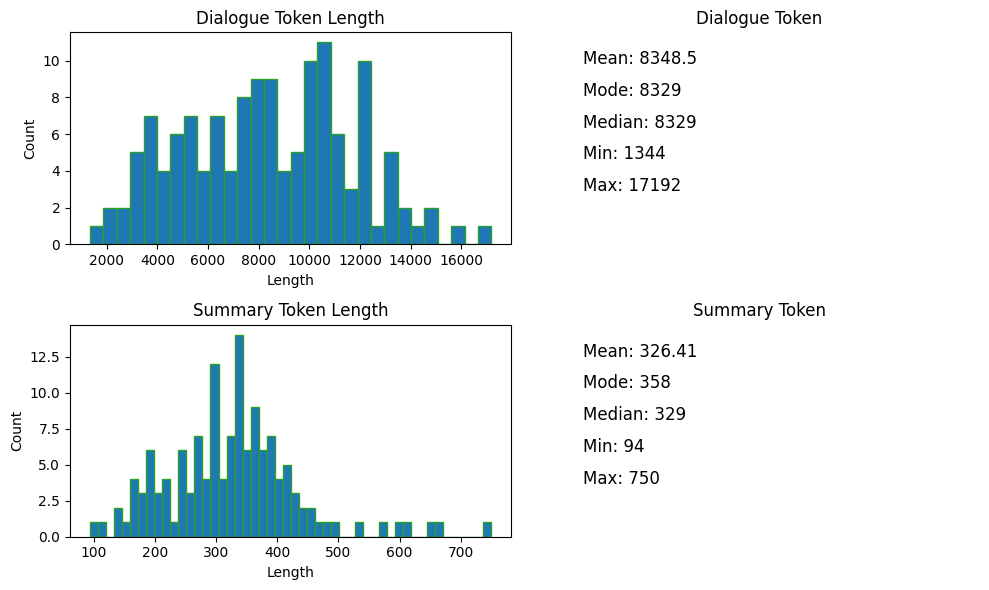

In [6]:
import matplotlib.pyplot as plt
import statistics

dialogue_token_len = list(len(tokenizer.encode(s)) for s in df['Dialogue'])
summary_token_len = list(len(tokenizer.encode(s)) for s in df['Summaries'])

fig, axes = plt.subplots(2, 2, figsize=(10, 6) )
axes[0,0].hist(dialogue_token_len, bins = 30, color = 'C0', edgecolor = 'C2' )
axes[0,0].set_title("Dialogue Token Length")
axes[0,0].set_xlabel("Length")
axes[0,0].set_ylabel("Count")

axes[0,1].set_title("Dialogue Token")
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['bottom'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['left'].set_visible(False)
axes[0,1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
axes[0,1].text(0.1, 0.85, "Mean: {}".format(round(statistics.mean(dialogue_token_len), 2)), fontsize=12)
axes[0,1].text(0.1, 0.70, "Mode: {}".format(statistics.mode(dialogue_token_len)), fontsize=12)
axes[0,1].text(0.1, 0.55, "Median: {}".format(statistics.median(dialogue_token_len)), fontsize=12)
axes[0,1].text(0.1, 0.40, "Min: {}".format(min(dialogue_token_len)), fontsize=12)
axes[0,1].text(0.1, 0.25, "Max: {}".format(max(dialogue_token_len)), fontsize=12)

axes[1,0].hist(summary_token_len, bins = 50, color = 'C0', edgecolor = 'C2' )
axes[1,0].set_title("Summary Token Length")
axes[1,0].set_xlabel("Length")
axes[1,0].set_ylabel("Count")

axes[1,1].set_title("Summary Token")
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['bottom'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].spines['left'].set_visible(False)
axes[1,1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
axes[1,1].text(0.1, 0.85, "Mean: {}".format(round(statistics.mean(summary_token_len), 2)), fontsize=12)
axes[1,1].text(0.1, 0.70, "Mode: {}".format(statistics.mode(summary_token_len)), fontsize=12)
axes[1,1].text(0.1, 0.55, "Median: {}".format(statistics.median(summary_token_len)), fontsize=12)
axes[1,1].text(0.1, 0.40, "Min: {}".format(min(summary_token_len)), fontsize=12)
axes[1,1].text(0.1, 0.25, "Max: {}".format(max(summary_token_len)), fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

ratios = []
for i in range(len(summary_token_len)):
    ratio = dialogue_token_len[i] / summary_token_len[i]
    ratios.append(ratio)

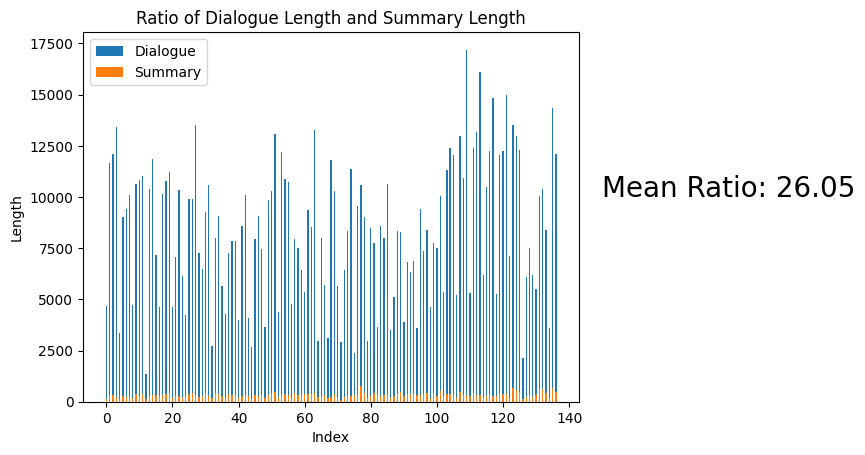

In [10]:
x = np.arange(len(summary_token_len))

plt.bar(x, dialogue_token_len, width=0.4, label='Dialogue', align='center')
plt.bar(x, summary_token_len, width=0.4, label='Summary', align='center')

plt.xlabel('Index')
plt.ylabel('Length')
plt.title('Ratio of Dialogue Length and Summary Length')
plt.text(150, 10000, "Mean Ratio: {}".format(round(statistics.mean(ratios), 2)), fontsize=20)
plt.legend()

plt.show()

In [151]:
print(text)

B: Okay .
B: Right .
B: Um well this is the kick-off meeting for our our project .
B: Um and um this is just what we're gonna be doing over the next twenty five minutes .
D: Mm-hmm .
B: Um so first of all , just to kind of make sure that we all know each other , I'm Laura and I'm the project manager .
B: Do you want to introduce yourself again ?
D: Great .
A: Hi , I'm David and I'm supposed to be an industrial designer .
B: Okay .
D: And I'm Andrew and I'm uh our marketing expert .
C: Um I'm Craig and I'm User Interface .
B: Great .
B: Okay .
B: Um so we're designing a new remote control and um Oh I have to record who's here actually .
B: So that's David , Andrew and Craig , isn't it ?
B: And you all arrived on time .
B: Um yeah so des uh design a new remote control .
B: Um , as you can see it's supposed to be original , trendy and user friendly .
B: Um so that's kind of our our brief , as it were .
B: Um and so there are three different stages to the design .
B: Um I'm not really sure

In [11]:
auto_tokens = (tokenizer(text))
len(auto_tokens.input_ids)

11655

In [13]:
import nltk
tokens = nltk.word_tokenize(text)
len(tokens)

9822

In [14]:
# Tokenize the sentences and count the total number of tokens
import nltk
def count_tokens(sentences):
    total_tokens = 0
    for sentence in sentences:
        tokens = nltk.word_tokenize(sentence)
        total_tokens += len(tokens)
    print("Total number of tokens is {}.".format(total_tokens))

# Splitting Sentences 

In [15]:
# Split text into sentences
import re
sentences = re.split(r'(?<=[.!?])\s+', text)

# Remve left colums
for i in range(len(sentences)):
    sentences[i] = sentences[i][3:]

count_tokens(sentences)

Total number of tokens is 8439.


# Removing stopwords

In [16]:
# Removing stopwords
import nltk
from nltk.corpus import stopwords
stopwords_set = set(stopwords.words('english'))
stopwords_removed = []
for sentence in sentences:
    words = sentence.split()
    filtered_words = [word for word in words if word.lower() not in stopwords_set]
    processed_sentence = ' '.join(filtered_words)
    stopwords_removed.append(processed_sentence)

count_tokens(stopwords_removed)

Total number of tokens is 4896.


In [17]:
stopwords_removed

['alright ?',
 'Okay .',
 'Sorry ?',
 'Okay , everybody set start meeting ?',
 "Okay , we've got half hour one um uh discuss um functional design .",
 'Could plug ?',
 'Okay .',
 'Thanks .',
 'ready go ?',
 'Okay .',
 'Okay .',
 "Um hopefully working away , I've put minutes last meeting project folder .",
 'Um guess recap uh last time .',
 "Um kind uh got know little bit uh got familiar equipment started discuss um bit project , know , cost-wise much much money Um want tell three new requirements , um first one um uh company's decided teletext outdated uh popular internet .",
 'Nobody uses teletext much anymore , really need consider functionality remote control .',
 "'Kay .",
 "Um they've also suggested um use remote control control television , V_C_R_ , D_V_D_ anything else .",
 "think worry project becomes complex it'll affect um long takes us get production , time market .",
 'Okay .',
 "um , we're gonna keep simple it'll control T_V_ .",
 'thing company want corporate colour sloga

# Remove smol sentences

In [18]:
smol_sentences_removed = []
smol_sentences = []
threshold = 3

for sentence in stopwords_removed:
    if len(sentence.split()) >= threshold:
        smol_sentences_removed.append(sentence)
    else:
        smol_sentences.append(sentence)

count_tokens(smol_sentences_removed)

Total number of tokens is 4294.


In [19]:
smol_sentences_removed

['Okay , everybody set start meeting ?',
 "Okay , we've got half hour one um uh discuss um functional design .",
 'Could plug ?',
 'ready go ?',
 "Um hopefully working away , I've put minutes last meeting project folder .",
 'Um guess recap uh last time .',
 "Um kind uh got know little bit uh got familiar equipment started discuss um bit project , know , cost-wise much much money Um want tell three new requirements , um first one um uh company's decided teletext outdated uh popular internet .",
 'Nobody uses teletext much anymore , really need consider functionality remote control .',
 "Um they've also suggested um use remote control control television , V_C_R_ , D_V_D_ anything else .",
 "think worry project becomes complex it'll affect um long takes us get production , time market .",
 "um , we're gonna keep simple it'll control T_V_ .",
 'thing company want corporate colour slogan implemented new design .',
 "Um I'm entirely sure corporate colour .",
 'might yellow , seems lot yello

In [20]:
smol_sentences

['alright ?',
 'Okay .',
 'Sorry ?',
 'Okay .',
 'Thanks .',
 'Okay .',
 'Okay .',
 "'Kay .",
 'Okay .',
 'Sure .',
 'Mm-hmm .',
 'Right .',
 'Okay .',
 'Alright .',
 'Sorry .',
 'Oop .',
 'Um .',
 'Mm-hmm .',
 'Mm-hmm .',
 '',
 'Okay .',
 'Yeah .',
 'Larger ?',
 'Yeah .',
 'Yeah .',
 'Sure .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Uh-huh .',
 'Okay .',
 '?',
 'Yeah .',
 'Yeah .',
 '?',
 '?',
 'Yeah .',
 'Mm .',
 'right ?',
 'Yeah .',
 'Mm-hmm .',
 'Yeah .',
 'Yep .',
 'Okay .',
 'Yeah .',
 '.',
 '.',
 'Mm-hmm .',
 'Yeah .',
 'Sure .',
 '.',
 '.',
 '.',
 'Yeah .',
 'switch .',
 'Okay .',
 'Right .',
 'Um .',
 'Okay .',
 'Okay .',
 'Okay .',
 'Alright .',
 'Yeah .',
 'Mm .',
 'Okay .',
 'Mm-hmm .',
 'Yep .',
 'Nope .',
 'Try .',
 'Wait .',
 'Okay .',
 'go .',
 'Okay .',
 'Okay .',
 'Right .',
 'go .',
 'Okay .',
 'Alright .',
 'Okay .',
 'Yeah .',
 'Um .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Um .',
 'Mm-hmm .',
 'Okay .',
 'Yeah .',
 'Okay .',
 'Mm .',
 'Yeah .',
 '

# Combining Sentences into a single sentence

In [159]:
# Combining Sentences into a single sentence
combined_string = ' '.join(smol_sentences_removed)
print(combined_string)

Um well kick-off meeting project . Um um we're gonna next twenty five minutes . Um first , kind make sure know , I'm Laura I'm project manager . want introduce ? Hi , I'm David I'm supposed industrial designer . I'm Andrew I'm uh marketing expert . Um I'm Craig I'm User Interface . Um we're designing new remote control um Oh record who's actually . that's David , Andrew Craig , ? arrived time . Um yeah des uh design new remote control . Um , see supposed original , trendy user friendly . Um that's kind brief , . Um three different stages design . Um I'm really sure guys already received um emails . Um , got project announcement project . Designing remote control . That's , get anything else . Yeah , that's that's . everybody got ? get thing ? we're gonna like individual work meeting . repeat process three times . Um point get try whiteboard . uh get draw favourite animal sum favourite characteristics . would like go first ? That's fine . one , right ? favourite animal like beagle . Um 

# Making chunks

In [21]:
sentences = smol_sentences_removed

In [22]:
length = 0
chunk = ""
chunks = []
count = -1
for sentence in sentences:
    count += 1
    combined_length = len(tokenizer.tokenize(sentence)) + length # add the no. of sentence tokens to the length counter

    if combined_length  <= tokenizer.max_len_single_sentence: # if it doesn't exceed
        chunk += sentence + " " # add the  sentence to the chunk
        length = combined_length # update the length counter

        # if it is the last sentence
        if count == len(sentences) - 1:
            chunks.append(chunk.strip()) # save the chunk

    else: 
        chunks.append(chunk.strip()) # save the chunk
    
        # reset 
        length = 0 
        chunk = ""

        # take care of the overflow sentence
        chunk += sentence + " "
        length = len(tokenizer.tokenize(sentence))
len(chunks)

6

In [23]:
[len(tokenizer.tokenize(c)) for c in chunks]

[1009, 1004, 1020, 1020, 1013, 361]

In [24]:
[len(tokenizer(c).input_ids) for c in chunks]

[1010, 1005, 1021, 1021, 1014, 362]

In [25]:
inputs = [tokenizer(chunk, return_tensors="pt") for chunk in chunks]

# Summarization

In [37]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
checkpoint = "google/pegasus-large"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)

In [38]:
model.generate??

Signature:
model.generate(
    inputs: Union[torch.Tensor, NoneType] = None,
    generation_config: Union[transformers.generation.configuration_utils.GenerationConfig, NoneType] = None,
    logits_processor: Union[transformers.generation.logits_process.LogitsProcessorList, NoneType] = None,
    stopping_criteria: Union[transformers.generation.stopping_criteria.StoppingCriteriaList, NoneType] = None,
    prefix_allowed_tokens_fn: Union[Callable[[int, torch.Tensor], List[int]], NoneType] = None,
    synced_gpus: Union[bool, NoneType] = None,
    assistant_model: Union[ForwardRef('PreTrainedModel'), NoneType] = None,
    streamer: Union[ForwardRef('BaseStreamer'), NoneType] = None,
    **kwargs,
) -> Union[transformers.generation.utils.GreedySearchEncoderDecoderOutput, transformers.generation.utils.GreedySearchDecoderOnlyOutput, transformers.generation.utils.SampleEncoderDecoderOutput, transformers.generation.utils.SampleDecoderOnlyOutput, transformers.generation.utils.BeamSearchEncoderDe

In [42]:
for input in inputs:
    output = model.generate(**input)
    print(tokenizer.decode(*output, skip_special_tokens=True))

c:\users\harde\documents\dsc\envs\major\lib\site-packages\transformers\generation\utils.py:1346: UserWarning: Using `max_length`'s default (256) to control the generation length. This behaviour is deprecated and will be removed from the config in v5 of Transformers -- we recommend using `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Um kind uh got know little bit uh got familiar equipment started discuss um bit project, know, cost-wise much much money Um want tell three new requirements, um first one um uh company's decided teletext outdated uh popular internet. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um I've look previous products see offer um would like ask guys um ideas design end meeting.
Would like mine um channels like numbers thing, um Um, yeah. God, wou would say that's required, mean there's way anybody's gonna buy remote control days can't actually individually select channels, mean would anybody disagree? Um, else, uh need worry teletext, need 

In [190]:
from transformers import pipeline
summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")
summarizer(chunks[0])

[{'summary_text': 'Laura is project manager. David is industrial designer. Andrew is marketing expert. Craig is User Interface Designer. They are designing a new remote control. They will sell it for   Â£12.50.'}]

In [122]:
dialogue_token_len = [len(tokenizer.encode(s)) for s in combined_string ]
dialogue_token_len

[3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,


In [125]:
final_text = ''.join(sentences)
final_text = final_text.replace(' .', '. ')
final_text

"Okay. Right. Um well this is the kick-off meeting for our our project. Um and um this is just what we're gonna be doing over the next twenty five minutes. Mm-hmm. Um so first of all , just to kind of make sure that we all know each other , I'm Laura and I'm the project manager. Do you want to introduce yourself again ?Great. Hi , I'm David and I'm supposed to be an industrial designer. Okay. And I'm Andrew and I'm uh our marketing expert. Um I'm Craig and I'm User Interface. Great. Okay. Um so we're designing a new remote control and um Oh I have to record who's here actually. So that's David , Andrew and Craig , isn't it ?And you all arrived on time. Um yeah so des uh design a new remote control. Um , as you can see it's supposed to be original , trendy and user friendly. Um so that's kind of our our brief , as it were. Um and so there are three different stages to the design. Um I'm not really sure what what you guys have already received um in your emails. What did you get ?Um , I 

In [43]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL", "rougeLsum"], use_stemmer=True)

In [44]:
extracttive = '''
Um kind uh got know little bit uh got familiar equipment started discuss um bit project, know, cost-wise much much money Um want tell three new requirements, um first one um uh company's decided teletext outdated uh popular internet. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um I've look previous products see offer um would like ask guys um ideas design end meeting.
Would like mine um channels like numbers thing, um Um, yeah. God, wou would say that's required, mean there's way anybody's gonna buy remote control days can't actually individually select channels, mean would anybody disagree? Um, else, uh need worry teletext, need worry V_C_R_, uh kind like display controls think need worry, know like brightness contrast? Um, start um sort uh bit, um need find exactly um add things they're possible. Well, one one way would look um would approach different controls terms um like control types, user clear want go. Um, start um sort uh bit, um need find exactly um add things they're possible.
guess we're looking people want h technology, tend use simple controls overall find remote controls something really appeal. think we're we're trying take like sorta like three different um inspirations, know, one want uh something that's high-tech want seem easy. uh mention Craig uh showing us ideas actually try group controls, look like big panel, kinda like look, know, new computer keyboard, something quite explanatory. installing new remote control something people Um, think it'll mid range high end market, terms people. Um people uh additionally liking appearance products, wanna think wanna take sort of techie features um put unit people like. Yeah, know c looking Craig um Craig's uh thirty ideas sorta tell maybe wanna try um least five different things wanna include. Well, um one things decide end meeting we're gonna um who's target audience, target market.
think one thing try avoid say use speech recognition right, um, based go everybody's saying, right, want something simple. Um, I'm saying we're we're trying lock particular kind technology, rather focusing exactly features we're gonna say,, know, say speech recognition good, speech recognition good. maybe suggest think speech recognition, anyway something used fulfil function, end day look technology, look function first. Uh okay, well wanna um give us presentation know um might good idea deliver presentations discuss, we're right, exactly, yeah. Oh something that's occurred well make um speech reco incorporate speech recognition, that's um people um maybe physical disability well. We've used, we're familiar, we're can't n narrowed um exactly things we're trying fulfil, like Besides basics, think back back minds know basics.
Um might one consideration would transmission remote control T_V_ example. Okay, um gonna restrict using traditional technologies infra-red thing? Well well worry expressed new requirements made complex would e would effect um long long took us get market, th suspect might good idea restrict kind creative influence user interface worry much uh transmit um mean tried tested intra-red, could stay tha Mm-hmm Oh, yeah. may require, know, um something natural, guess, know, hold, signal user, push button maybe start talking.
Okay, gonna um audio gonna like know bass settings actual volume hi Okay. Okay, visual Okay, brightness, contrast, things like, actual device things, like channel watching, turning, stuff like. Um yeah, guess things think know like fact gotta look good, we're we're, know, targeting.'''

In [45]:
scores = scorer.score(extracttive, summry)

In [46]:
scores

{'rouge1': Score(precision=0.22108843537414966, recall=0.09803921568627451, fmeasure=0.13584117032392892),
 'rouge2': Score(precision=0.023890784982935155, recall=0.010574018126888218, fmeasure=0.014659685863874344),
 'rougeL': Score(precision=0.08503401360544217, recall=0.03770739064856712, fmeasure=0.0522466039707419),
 'rougeLsum': Score(precision=0.20068027210884354, recall=0.0889894419306184, fmeasure=0.12330198537095088)}

In [47]:
from transformers import pipeline
summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")
summarizer(extracttive)

[{'summary_text': 'The company has decided teletext is outdated and needs a new remote control control. The company is planning to create a new product with speech recognition and focusing on features for high-end market.'}]